# Sample-Level OOV Analysis of Chemical Formulae

This notebook analyzes the **sample-level out-of-vocabulary (OOV) rate of chemical formulae (CFs)** across different dataset splits. The goal is to quantify how often peaks in test spectra contain chemical formulae that **never appeared in the training set**, and to compare this behavior across different split strategies.

Understanding OOV rates is important because many machine learning models implicitly assume that the test distribution is similar to the training distribution. If a large fraction of peaks in the test set correspond to chemical formulae that were never observed during training, model performance may degrade due to distribution shift.

In particular, we hypothesize that the LS split is a more challenging split precisely because of this reason

# Overview of the Pipeline

The notebook proceeds in three steps:

### Step 1: Cache training-set chemical formulae
For each dataset and split, we extract and cache the **set of chemical formulae that appear in the training spectra**.  
This step avoids repeatedly recomputing the same information and speeds up later analysis.

### Step 2: Compute sample-level OOV rate
For each test spectrum, we compute the **sample-level OOV rate**, defined as the proportion of peaks whose chemical formulae do **not appear in the training set**.

Formally, for a test spectrum \(i\):

$$
\text{OOV}_i =
\frac{\# \text{peaks with CF not in training set}}{\# \text{peaks in spectrum}}
$$

These values are cached for later statistical analysis.



### Step 3: Compare OOV rates across splits
Finally, we compare the sample-level OOV distributions between different dataset splits.  
In particular, we test whether the **LS split produces higher OOV rates** than other splits (e.g., random or scaffold splits).

We perform a **Welch's t-test** to compare the distributions:

$$
H_0: \mu_{\text{LS}} \le \mu_{\text{split}}
$$

$$
H_1: \mu_{\text{LS}} > \mu_{\text{split}}
$$

This evaluates whether the LS split leads to a statistically higher fraction of unseen chemical formulae.

# Outputs

For each dataset and split, the notebook reports:

- mean sample-level OOV rate
- statistical significance of the test


Import libraries

In [1]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from utils import load_pickle, pickle_data, load_json

import torch

Settings

In [8]:
data_folder = Path("../data/processed_data")
splits_folder = Path("../data/splits")
cache_folder = Path("../results/OOV_CF_analysis")
if not os.path.exists(cache_folder): os.makedirs(cache_folder)

datasets = ["NPLIB1", "massspecgym", "nist2023"]
splits = ["random", "scaffold", "LS"]
colors = ["#575761", "#648381", "#98B9AB", "#9BC995"][::-1]

Helper Functions

In [ ]:
def get_CFs_train(data, train_ids):

    train_CFs = set() 

    for rec in tqdm(data): 

        if str(rec["id_"]) not in train_ids: continue 

        CFs = set([f["comment"]["f_pred"] for f in rec["peaks"]])
        CFs.discard("")
        train_CFs.update(CFs)

    return train_CFs

def compute_sample_level_OOV_rate(train_CFs, data, test_ids):

    oov_rate_list = []

    for rec in tqdm(data):

        if str(rec["id_"]) not in test_ids: continue 

        CFs = set([f["comment"]["f_pred"] for f in rec["peaks"]])
        CFs.discard("")

        if len(CFs) == 0:
            oov_rate = 1.0
        else:
            oov_rate = np.mean([f not in train_CFs for f in CFs]).item()
        
        oov_rate_list.append(oov_rate)

    return oov_rate_list

Step 1: Cache the chemical formula (CFs) of all the peaks in the training set

In [ ]:
for dataset in datasets:

    for split in splits: 
        
        output_folder = cache_folder / dataset / split
        output_path = output_folder / "train_CFs.pkl"
        if os.path.exists(output_path): 
            print(f"Cache for CF of training samples for {dataset} ({split} split) created. Skipping.")
            continue

        # Create the folder 
        if not os.path.exists(output_folder): os.makedirs(output_folder)

        # Load the data 
        data_path = data_folder / f"{dataset}.pkl"
        data = load_pickle(data_path)
        print(f"Loaded data: {dataset}")

        # Load the split 
        split_ids = load_json(splits_folder / dataset / f"{split}.json")
        train_ids = [t.replace(".pkl", "") for t in split_ids["train"]]

        # Get CFs that appeared in the training set
        train_CFs = get_CFs_train(data, train_ids)

        # Save the data 
        pickle_data(train_CFs, output_path)
        print(f"Got all the chemical formula that appeared in the training set for {dataset} ({split} split).")

Step 2: Compute and cache sample level OOV rate

In [5]:
for dataset in datasets:

    for split in splits: 
        
        output_folder = cache_folder / dataset / split
        output_path = output_folder / "test_sample_level_OOV_rate.pkl"
        if os.path.exists(output_path): 
            print(f"Cache for sample level oov rate for the test samples for {dataset} ({split} split) created. Skipping.")
            continue

        # Get the training level OOV rate
        train_CFs_path = output_folder / "train_CFs.pkl"
        if not os.path.exists(train_CFs_path):
            raise Exception(f"Make sure to cache the train CF by running the previous cell.")
        train_CFs = load_pickle(train_CFs_path)

        # Load the data 
        data_path = data_folder / f"{dataset}.pkl"
        data = load_pickle(data_path)
        print(f"Loaded data: {dataset}")

        # Load the split 
        split_ids = load_json(splits_folder / dataset / f"{split}.json")
        test_ids = [t.replace(".pkl", "") for t in split_ids["test"]]

        # Get sample level OOV rate 
        sample_level_oov = compute_sample_level_OOV_rate(train_CFs, data, test_ids)
        pickle_data(sample_level_oov, output_path)


Cache for sample level oov rate for the test samples for NPLIB1 (random split) created. Skipping.
Cache for sample level oov rate for the test samples for NPLIB1 (scaffold split) created. Skipping.
Cache for sample level oov rate for the test samples for NPLIB1 (LS split) created. Skipping.
Cache for sample level oov rate for the test samples for massspecgym (random split) created. Skipping.
Cache for sample level oov rate for the test samples for massspecgym (scaffold split) created. Skipping.
Cache for sample level oov rate for the test samples for massspecgym (LS split) created. Skipping.


Step 3: Compare the sample level OOV rate against the LS split

In [ ]:
for dataset in datasets:

    for split in splits: 
        
        if split == "LS": continue 

        # Get the sample level OOV rate for the LS split 
        LS_sample_level_oov_rate_path = output_path = cache_folder / dataset / "LS" / "test_sample_level_OOV_rate.pkl"
        if not os.path.exists(LS_sample_level_oov_rate_path):
            raise Exception(f"Make sure to get the sample level OOV rate for the LS split by running the previous cell.")
        LS_sample_level_oov_rate = load_pickle(LS_sample_level_oov_rate_path)
        
        # Get the sample level OOV rate for the current split 
        sample_level_oov_rate_path = output_path = cache_folder / dataset / split / "test_sample_level_OOV_rate.pkl"
        if not os.path.exists(sample_level_oov_rate_path):
            raise Exception(f"Make sure to get the sample level OOV rate for the {split} split by running the previous cell.")
        sample_level_oov_rate = load_pickle(sample_level_oov_rate_path)
    
        # Compute Welch's t-test
        t, p = ttest_ind(LS_sample_level_oov_rate, sample_level_oov_rate, equal_var=False, alternative="greater") # Check if this is higher in the LS split

        # Look at the oov rate
        print(dataset, split, round(np.mean(sample_level_oov_rate) * 100, 3), p)

Step 4: Plot the curve

/tmp/ipykernel_83332/2838185727.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_83332/2838185727.py:37: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.barplot(
/tmp/ipykernel_83332/2838185727.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["Group"], fontsize = 15)


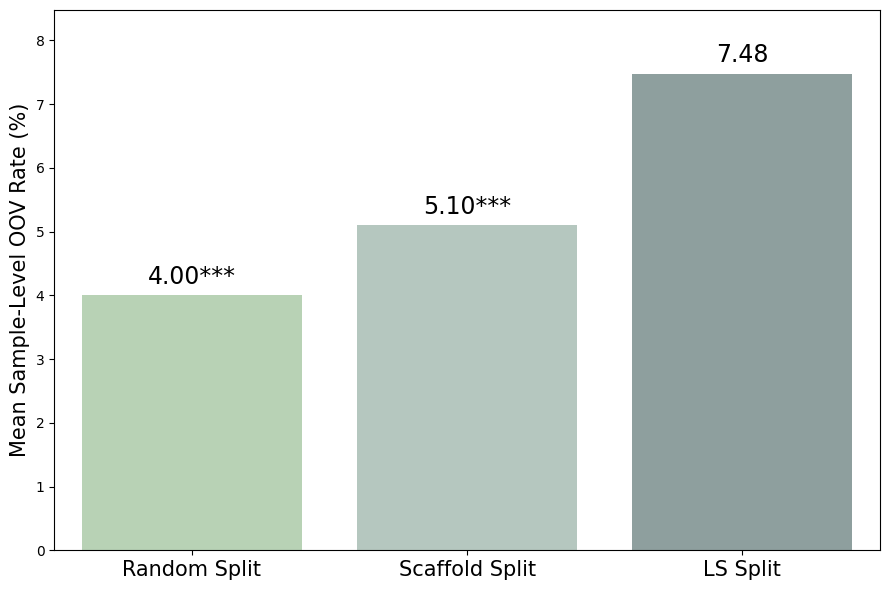

/tmp/ipykernel_83332/2838185727.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_83332/2838185727.py:37: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.barplot(
/tmp/ipykernel_83332/2838185727.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["Group"], fontsize = 15)


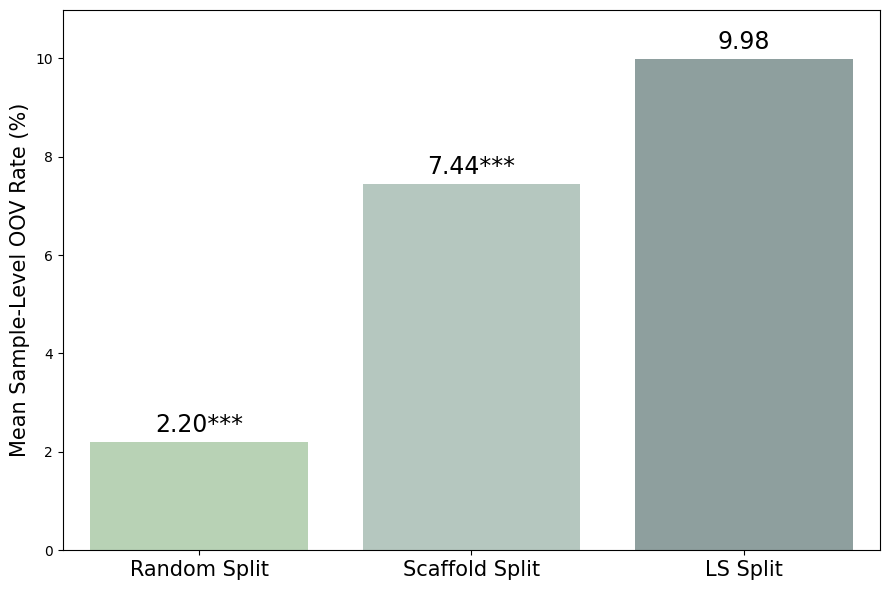

In [11]:
for dataset in datasets: 

    if dataset == "nist2023": continue

    LS_sample_level_oov_rate_path = output_path = cache_folder / dataset / "LS" / "test_sample_level_OOV_rate.pkl"
    scaffold_sample_level_oov_rate_path = output_path = cache_folder / dataset / "scaffold" / "test_sample_level_OOV_rate.pkl"
    random_sample_level_oov_rate_path = output_path = cache_folder / dataset / "random" / "test_sample_level_OOV_rate.pkl"

    LS_sample_level_oov_rate = load_pickle(LS_sample_level_oov_rate_path)
    scaffold_sample_level_oov_rate = load_pickle(scaffold_sample_level_oov_rate_path)
    random_sample_level_oov_rate = load_pickle(random_sample_level_oov_rate_path)

    oov_ls = np.mean(LS_sample_level_oov_rate) * 100
    oov_scaffold = np.mean(scaffold_sample_level_oov_rate) * 100
    oov_random = np.mean(random_sample_level_oov_rate) * 100

    # Create flat dataframe
    data = {
        "Group": ["LS Split"] +
                 ["Scaffold Split"]+
                 ["Random Split"] ,
        "OOV": [oov_ls, oov_scaffold, oov_random]
    }
    df = pd.DataFrame(data)

    # Calculate mean OOV for each group
    summary_df = df.groupby("Group")["OOV"].mean().reset_index()
    summary_df["Group"] = pd.Categorical(summary_df["Group"], categories=[
        "Random Split", "Scaffold Split", "LS Split"
    ], ordered=True)
    summary_df = summary_df.sort_values("Group")

    # Plot
    plt.figure(figsize=(9, 6))

    # Draw bar plot
    ax = sns.barplot(
        data=summary_df,
        x="Group",
        y="OOV", palette = colors, alpha = 0.75)

    # Overlay red curve (line connecting bar tops)
    x = np.arange(len(summary_df))
    y = summary_df["OOV"].values

    # Add values and p-values
    x = np.arange(len(summary_df))
    y = summary_df["OOV"].values
    group_names = summary_df["Group"].values

    # Statistical tests
    p_values = {}
    p_values["Random Split"] = ttest_ind(LS_sample_level_oov_rate, random_sample_level_oov_rate, equal_var=False, alternative="greater").pvalue
    p_values["Scaffold Split"] = ttest_ind(LS_sample_level_oov_rate, scaffold_sample_level_oov_rate, equal_var=False, alternative="greater").pvalue

    for i, (val, group) in enumerate(zip(y, group_names)):
        
        if group != "LS Split":
            pval = p_values[group]
            if pval < 0.001:
                p_text = "***"
            elif pval < 0.01:
                p_text = "**"
            elif pval < 0.05:
                p_text = "*"
            else:
                p_text = "n.s."
        
        else: p_text = ""
        add_text = 0.1
        if dataset == "nist2023": add_text = 0.05
        ax.text(i, val + add_text, f"{val:.2f}" + p_text, ha="center", va="bottom", fontsize=17)

    # Final plot customizations
    ax.set_ylabel("Mean Sample-Level OOV Rate (%)", fontsize = 15)
    add = 1.0
    if dataset == "nist2023": add = 0.3
    ax.set_ylim(0, max(y) + add)
    ax.set_xlabel("")
    ax.set_xticklabels(summary_df["Group"], fontsize = 15)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"../figures/OOV_{dataset}.png", dpi=300, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_83332/4229703950.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary_df, x="Group", y="OOV", palette=colors, alpha=0.75)
/tmp/ipykernel_83332/4229703950.py:20: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.barplot(data=summary_df, x="Group", y="OOV", palette=colors, alpha=0.75)
/tmp/ipykernel_83332/4229703950.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["Group"], fontsize=15)


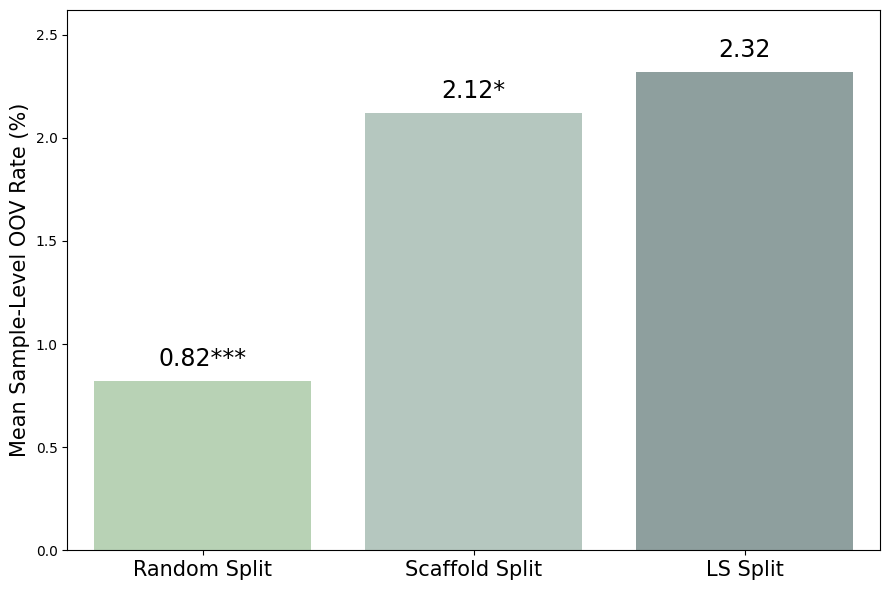

In [16]:
def plot_oov_from_values(dataset, oov_ls, oov_scaffold, oov_random,
                         p_ls_vs_random, p_ls_vs_scaffold,
                         y_add=1.0, text_add=0.1):
    """
    dataset: str, dataset name (for title/save)
    oov_ls, oov_scaffold, oov_random: mean OOV rates in % (already multiplied by 100)
    p_ls_vs_random, p_ls_vs_scaffold: p-values from one-sided Welch's t-test (LS > other)
    """
    data = {
        "Group": ["Random Split", "Scaffold Split", "LS Split"],
        "OOV": [oov_random, oov_scaffold, oov_ls]
    }
    summary_df = pd.DataFrame(data)
    summary_df["Group"] = pd.Categorical(summary_df["Group"], categories=[
        "Random Split", "Scaffold Split", "LS Split"
    ], ordered=True)
    summary_df = summary_df.sort_values("Group")

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(data=summary_df, x="Group", y="OOV", palette=colors, alpha=0.75)

    y = summary_df["OOV"].values
    group_names = summary_df["Group"].values
    p_values = {"Random Split": p_ls_vs_random, "Scaffold Split": p_ls_vs_scaffold}

    for i, (val, group) in enumerate(zip(y, group_names)):
        if group != "LS Split":
            pval = p_values[group]
            if pval < 0.001:
                p_text = "***"
            elif pval < 0.01:
                p_text = "**"
            elif pval < 0.05:
                p_text = "*"
            else:
                p_text = "n.s."
        else:
            p_text = ""
        ax.text(i, val + text_add, f"{val:.2f}" + p_text, ha="center", va="bottom", fontsize=17)

    ax.set_ylabel("Mean Sample-Level OOV Rate (%)", fontsize=15)
    ax.set_ylim(0, max(y) + y_add)
    ax.set_xlabel("")
    ax.set_xticklabels(summary_df["Group"], fontsize=15)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"../figures/OOV_{dataset}.png", dpi=300, bbox_inches="tight")
    plt.show()


# Example usage — hardcode values here:
plot_oov_from_values(
    dataset="nist2023",
    oov_ls=2.32,       # mean OOV % for LS split
    oov_scaffold=2.12,  # mean OOV % for scaffold split
    oov_random=0.82,    # mean OOV % for random split
    p_ls_vs_random=0.0001,
    p_ls_vs_scaffold=0.015,
    y_add=0.3,
    text_add=0.05,
)